In [ ]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install folium
!pip install geopandas
!pip install rasterio
!pip install scikit-learn
!pip install xgboost
!pip install lightgbm
!pip install catboost
!pip install libpysal
!pip install esda
!pip install geoip2
!pip install branca
!pip install shapely
!pip install pyproj
!pip install fiona
!pip install networkx
!pic install shap

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import geopandas as gpd
import rasterio
import ipaddress

from folium.plugins import HeatMap

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.utils import resample

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from libpysal.weights import KNN
from esda.moran import Moran
from esda.getisord import G_Local

import geoip2.database

C:\Users\himel\Downloads\Hotspots of Cybercrime in Identifying High-Risk Areas through Geospatial Analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv(
    'updated_cybersecurity_attacks.csv',
    encoding='latin1')

In [3]:
# FEATURE ENGINEERING

df.fillna("Unknown", inplace=True)

df.drop_duplicates(inplace=True)

df['Timestamp'] = pd.to_datetime(
    df['Timestamp'],
    errors='coerce',
    dayfirst=True
)

df['hour'] = df['Timestamp'].dt.hour
df['day_of_week'] = df['Timestamp'].dt.dayofweek
df['month'] = df['Timestamp'].dt.month

text_cols = [
    'Protocol',
    'Traffic Type',
    'Attack Type',
    'Severity Level'
]

df[text_cols] = df[text_cols].apply(
    lambda x: x.str.lower()
)

def ip_to_int(ip):
    try:
        return int(ipaddress.ip_address(ip))
    except:
        return np.nan

df['source_ip_numeric'] = (
    df['Source IP Address']
    .apply(ip_to_int)
)

In [5]:
reader = geoip2.database.Reader(
    'GeoLite2-City.mmdb'
)

def get_location(ip):

    try:

        response = reader.city(ip)

        return pd.Series([

            response.location.latitude,
            response.location.longitude,
            response.country.name,
            response.city.name

        ])

    except:

        return pd.Series([
            None,
            None,
            None,
            None
        ])

df[['Latitude',
    'Longitude',
    'Country',
    'City']] = (
        df['Source IP Address']
        .apply(get_location)
)

reader.close()

df['Latitude'] = pd.to_numeric(
    df['Latitude'],
    errors='coerce'
)

df['Longitude'] = pd.to_numeric(
    df['Longitude'],
    errors='coerce'
)

df = df[
    (df['Latitude'].between(-90, 90))
]

df = df[
    (df['Longitude'].between(-180, 180))
]

In [6]:
internet_df = pd.read_csv(
    'internet_users.csv'
)

gdp_df = pd.read_csv(
    'gdp_per_capita.csv'
)

population_df = pd.read_csv(
    'population_density.csv'
)

In [7]:
internet_df = internet_df[
    ['Country Name', '2023 [YR2023]']
]

internet_df.columns = [
    'Country',
    'Internet_Users'
]

gdp_df = gdp_df[
    ['Country Name', '2023 [YR2023]']
]

gdp_df.columns = [
    'Country',
    'GDP_Per_Capita'
]

population_df = population_df[
    ['Country Name', '2023 [YR2023]']
]

population_df.columns = [
    'Country',
    'Population_Density'
]

df = df.merge(
    internet_df,
    on='Country',
    how='left'
)

df = df.merge(
    gdp_df,
    on='Country',
    how='left'
)

df = df.merge(
    population_df,
    on='Country',
    how='left'
)

In [8]:
worldpop = rasterio.open(
    'global_pop_2020_CN_1km_R2025A_UA_v1.tif'
)

# READ BAND ONLY ONCE
population_band = worldpop.read(1)

# FAST FUNCTION
def get_population_density(lat, lon):

    try:

        row, col = worldpop.index(
            lon,
            lat
        )

        return population_band[row, col]

    except:

        return np.nan

# APPLY
df['local_population_density'] = [

    get_population_density(lat, lon)

    for lat, lon in zip(
        df['Latitude'],
        df['Longitude']
    )
]

In [9]:
# ASN / ISP ENRICHMENT

asn_reader = geoip2.database.Reader(
    'GeoLite2-ASN.mmdb'
)

def get_asn_info(ip):

    try:

        response = asn_reader.asn(ip)

        return pd.Series([
            response.autonomous_system_number,
            response.autonomous_system_organization
        ])

    except:

        return pd.Series([
            None,
            None
        ])

df[['ASN', 'ASN_Organization']] = (

    df['Source IP Address']
    .apply(get_asn_info)
)

In [10]:
# CREATE HIGH RISK LABEL

df['High_Risk'] = (
    df['Severity Level']
    .apply(
        lambda x:
            1 if x in ['high', 'critical']
            else 0
    )
)


# ASN FEATURES

df['asn_attack_count'] = (
    df.groupby('ASN')['Attack Type']
      .transform('count')
)

df['asn_risk_score'] = (
    df.groupby('ASN')['High_Risk']
      .transform('mean')
)

# COUNTRY FEATURES

df['country_attack_count'] = (
    df.groupby('Country')['Attack Type']
      .transform('count')
)

In [11]:
#FEATURE ENGINEERING

worldbank_cols = [

    'Internet_Users',
    'GDP_Per_Capita',
    'Population_Density'

]

for col in worldbank_cols:

    df[col] = (

        df[col]
        .astype(str)
        .str.replace(',', '')

    )

    df[col] = pd.to_numeric(
        df[col],
        errors='coerce'
    )

df[worldbank_cols] = (
    df[worldbank_cols]
    .fillna(0)
)

df['attack_per_density'] = (

    df['country_attack_count'] /

    (df['Population_Density'] + 1)

)

df['internet_risk_score'] = (

    df['country_attack_count'] /

    (df['Internet_Users'] + 1)

)

df['economic_risk_score'] = (

    df['country_attack_count'] /

    (df['GDP_Per_Capita'] + 1)

)

df['anomaly_time'] = (
    df['Anomaly Scores'] *
    df['hour']
)


# LABEL ENCODING

cat_cols = [

    'Protocol',
    'Traffic Type',
    'Attack Type',
    'Country',
    'City'

]

for col in cat_cols:

    df[col] = (
        LabelEncoder()
        .fit_transform(
            df[col].astype(str)
        )
    )

In [13]:
# DBSCAN CLUSTERING

cluster_features = [

    'Latitude',
    'Longitude',
    'local_population_density',
    'asn_risk_score'

]

coords = (
    df[cluster_features]
    .fillna(0)
)

coords_scaled = (
    StandardScaler()
    .fit_transform(coords)
)

db = DBSCAN(
    eps=0.5,
    min_samples=10
)

df['Cluster'] = (
    db.fit_predict(coords_scaled)
)

In [14]:
# CLUSTER RISK


df['cluster_risk'] = (

    df.groupby('Cluster')['High_Risk']
      .transform('mean')

)


# FINAL HOTSPOT SCORE


df['final_hotspot_score'] = (

      0.30 * df['Anomaly Scores']
    + 0.25 * df['asn_risk_score']
    + 0.20 * df['attack_per_density']
    + 0.15 * df['internet_risk_score']
    + 0.10 * df['cluster_risk']

)


# FINAL FEATURES


features = [

    'Latitude',
    'Longitude',
    'Protocol',
    'Traffic Type',
    'Attack Type',
    'Anomaly Scores',

    'Internet_Users',
    'GDP_Per_Capita',
    'Population_Density',

    'local_population_density',

    'asn_attack_count',
    'asn_risk_score',

    'attack_per_density',
    'internet_risk_score',
    'economic_risk_score',

    'cluster_risk',
    'final_hotspot_score',

    'day_of_week',
    'hour',
    'month'
]


# HANDLE MISSING VALUES


df[features] = (
    df[features]
    .fillna(0)
)


# BALANCE DATASET


df_majority = df[
    df.High_Risk == 0
]

df_minority = df[
    df.High_Risk == 1
]

df_minority_upsampled = resample(

    df_minority,

    replace=True,

    n_samples=len(df_majority),

    random_state=42

)

df_balanced = pd.concat([
    df_majority,
    df_minority_upsampled
])

In [15]:
# TRAIN TEST SPLIT


X = df_balanced[features]

y = df_balanced['High_Risk']

X_train, X_test, y_train, y_test = (

    train_test_split(

        X,
        y,
        test_size=0.2,
        random_state=42

    )

)

In [16]:
# XGBOOST MODEL


xgb_model = XGBClassifier(

    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss'

)

xgb_model.fit(
    X_train,
    y_train
)

xgb_preds = (
    xgb_model.predict(X_test)
)

print("XGBoost Accuracy:")

print(
    accuracy_score(
        y_test,
        xgb_preds
    )
)

print(
    classification_report(
        y_test,
        xgb_preds
    )
)

XGBoost Accuracy:
0.7170079635949943
              precision    recall  f1-score   support

           0       0.72      0.70      0.71      5236
           1       0.71      0.74      0.72      5312

    accuracy                           0.72     10548
   macro avg       0.72      0.72      0.72     10548
weighted avg       0.72      0.72      0.72     10548



In [17]:
# RANDOM FOREST


rf = RandomForestClassifier(
    n_estimators=200
)

rf.fit(
    X_train,
    y_train
)

rf_preds = rf.predict(X_test)

print("Random Forest Accuracy:")

print(
    accuracy_score(
        y_test,
        rf_preds
    )
)

print(
    classification_report(
        y_test,
        rf_preds
    )
)

Random Forest Accuracy:
0.8523890784982935
              precision    recall  f1-score   support

           0       0.85      0.86      0.85      5236
           1       0.86      0.85      0.85      5312

    accuracy                           0.85     10548
   macro avg       0.85      0.85      0.85     10548
weighted avg       0.85      0.85      0.85     10548



In [18]:
# LIGHTGBM


lgb = LGBMClassifier(
    n_estimators=200
)

lgb.fit(
    X_train,
    y_train
)

lgb_preds = lgb.predict(X_test)

print("lightgbm Accuracy:")

print(
    accuracy_score(
        y_test,
        lgb_preds
    )
)

print(
    classification_report(
        y_test,
        lgb_preds
    )
)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 21058, number of negative: 21134
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.017098 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2457
[LightGBM] [Info] Number of data points in the train set: 42192, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499099 -> initscore=-0.003603
[LightGBM] [Info] Start training from score -0.003603
lightgbm Accuracy:
0.6761471368979901
              precision    recall  f1-score   support

           0       0.68      0.66      0.67      5236
           1       0.67      0.69      0.68      5312

    accuracy                           0.68     10548
   macro avg       0.68      0.68      0.68     10548
weighted avg       0.68      0.68      0.68     10548



In [19]:
# CATBOOST


cat = CatBoostClassifier(
    verbose=0
)

cat.fit(
    X_train,
    y_train
)

cat_preds = cat.predict(X_test)

print("catboost Accuracy:")

print(
    accuracy_score(
        y_test,
        cat_preds
    )
)

print(
    classification_report(
        y_test,
        cat_preds
    )
)

catboost Accuracy:
0.6709328782707622
              precision    recall  f1-score   support

           0       0.67      0.66      0.67      5236
           1       0.67      0.68      0.68      5312

    accuracy                           0.67     10548
   macro avg       0.67      0.67      0.67     10548
weighted avg       0.67      0.67      0.67     10548



In [20]:
# ENSEMBLE PREDICTIONS


final_preds = (

    xgb_preds +
    rf_preds +
    lgb_preds +
    cat_preds

) / 4

final_preds = (
    final_preds > 0.5
).astype(int)

print("ENSEMBLE ACCURACY")

print(
    accuracy_score(
        y_test,
        final_preds
    )
)

print(
    classification_report(
        y_test,
        final_preds
    )
)

ENSEMBLE ACCURACY
0.7347364429275692
              precision    recall  f1-score   support

           0       0.71      0.78      0.75      5236
           1       0.76      0.69      0.72      5312

    accuracy                           0.73     10548
   macro avg       0.74      0.74      0.73     10548
weighted avg       0.74      0.73      0.73     10548



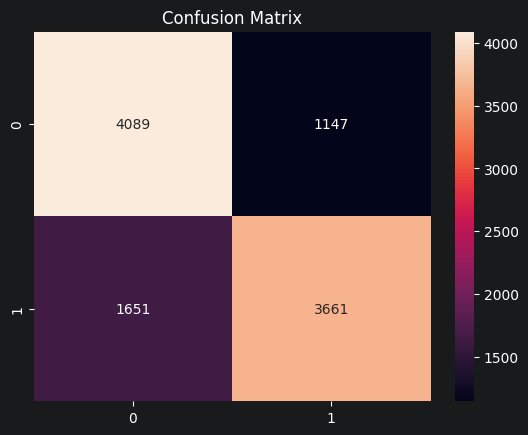

In [21]:
# CONFUSION MATRIX


cm = confusion_matrix(
    y_test,
    final_preds
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "Confusion Matrix"
)

plt.show()

In [22]:
# GEOSPATIAL ANALYSIS


gdf = gpd.GeoDataFrame(

    df,

    geometry=gpd.points_from_xy(
        df.Longitude,
        df.Latitude
    )

)

In [23]:
# MORAN'S I


w = KNN.from_dataframe(
    gdf,
    k=5
)

w.transform = 'r'

moran = Moran(
    gdf['Anomaly Scores'],
    w
)

print("Moran's I:")

print(moran.I)

C:\Users\himel\Downloads\Hotspots of Cybercrime in Identifying High-Risk Areas through Geospatial Analysis\.venv\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 263 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


Moran's I:
0.0033900219814291914


In [24]:
# GETIS-ORD GI*


g_local = G_Local(
    gdf['Anomaly Scores'],
    w
)

gdf['GiZScore'] = g_local.Zs

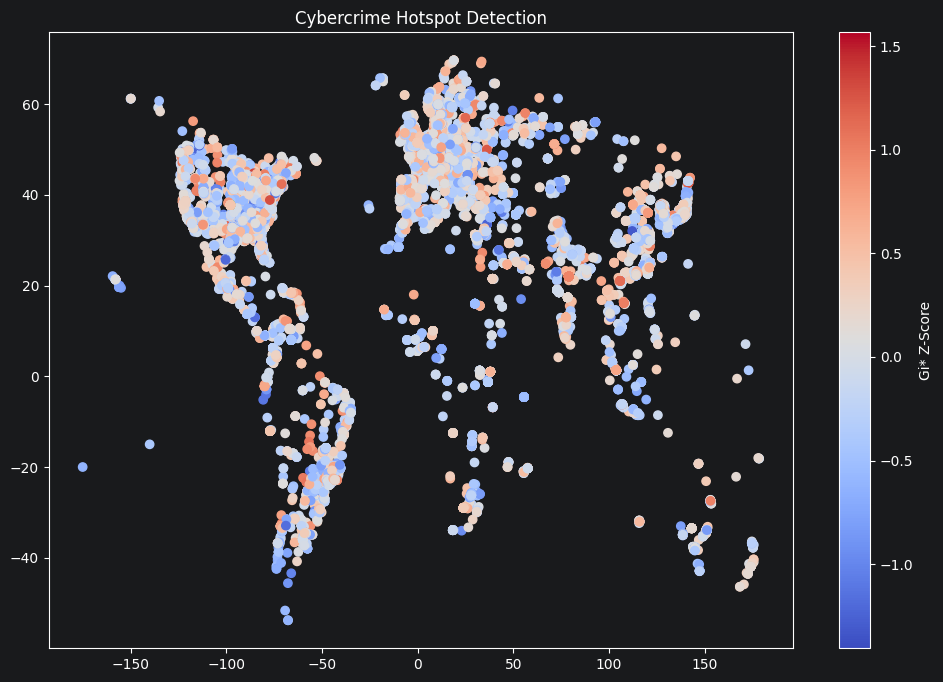

In [25]:
# HOTSPOT VISUALIZATION


plt.figure(figsize=(12, 8))

plt.scatter(

    gdf['Longitude'],
    gdf['Latitude'],

    c=gdf['GiZScore'],

    cmap='coolwarm'

)

plt.colorbar(
    label='Gi* Z-Score'
)

plt.title(
    "Cybercrime Hotspot Detection"
)

plt.show()

In [33]:
# FOLIUM HEATMAP


map_center = [

    df['Latitude'].mean(),
    df['Longitude'].mean()

]

heat_map = folium.Map(
    location=map_center,
    zoom_start=2
)

heat_data = df[
    ['Latitude', 'Longitude']
].values.tolist()

HeatMap(
    heat_data
).add_to(heat_map)

heat_map

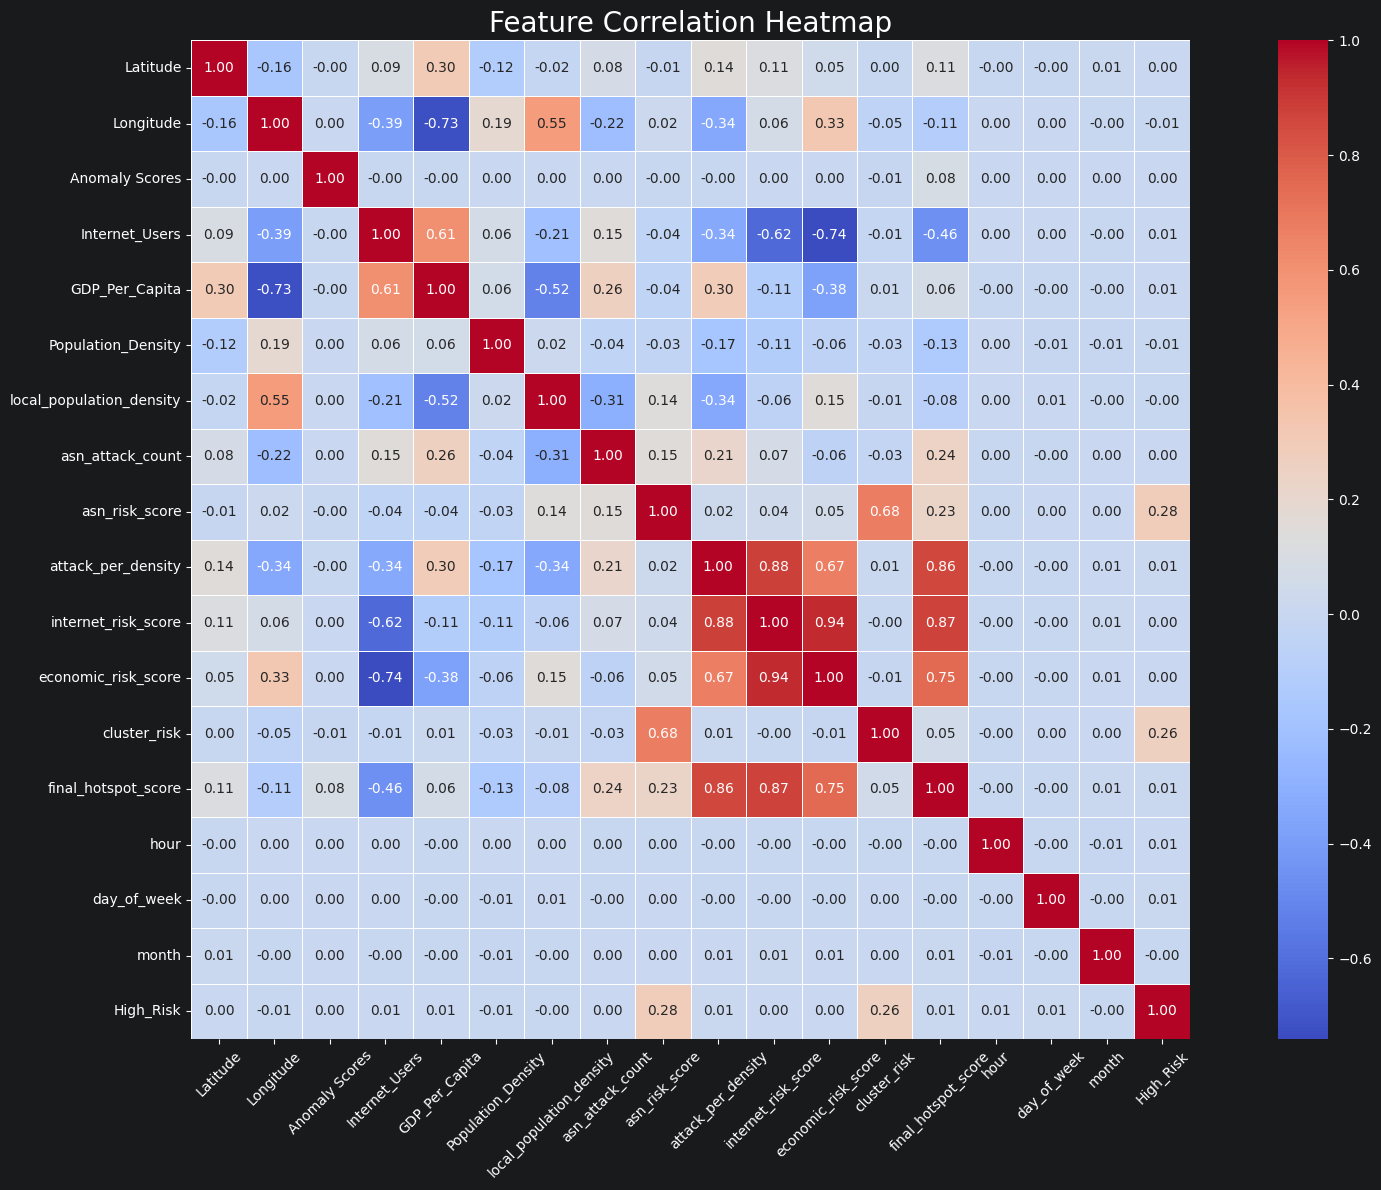

In [27]:
# SELECT NUMERIC FEATURES
# =========================================

corr_features = [

    'Latitude',
    'Longitude',

    'Anomaly Scores',

    'Internet_Users',
    'GDP_Per_Capita',
    'Population_Density',

    'local_population_density',

    'asn_attack_count',
    'asn_risk_score',

    'attack_per_density',
    'internet_risk_score',
    'economic_risk_score',

    'cluster_risk',
    'final_hotspot_score',

    'hour',
    'day_of_week',
    'month',

    'High_Risk'
]

# =========================================
# CREATE CORRELATION MATRIX
# =========================================

corr_matrix = (

    df[corr_features]
    .corr(numeric_only=True)
)

# =========================================
# PLOT HEATMAP
# =========================================

plt.figure(figsize=(18, 12))

sns.heatmap(

    corr_matrix,

    annot=True,
    fmt='.2f',

    cmap='coolwarm',

    linewidths=0.5,

    square=True
)

plt.title(
    'Feature Correlation Heatmap',
    fontsize=20
)

plt.xticks(rotation=45)

plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

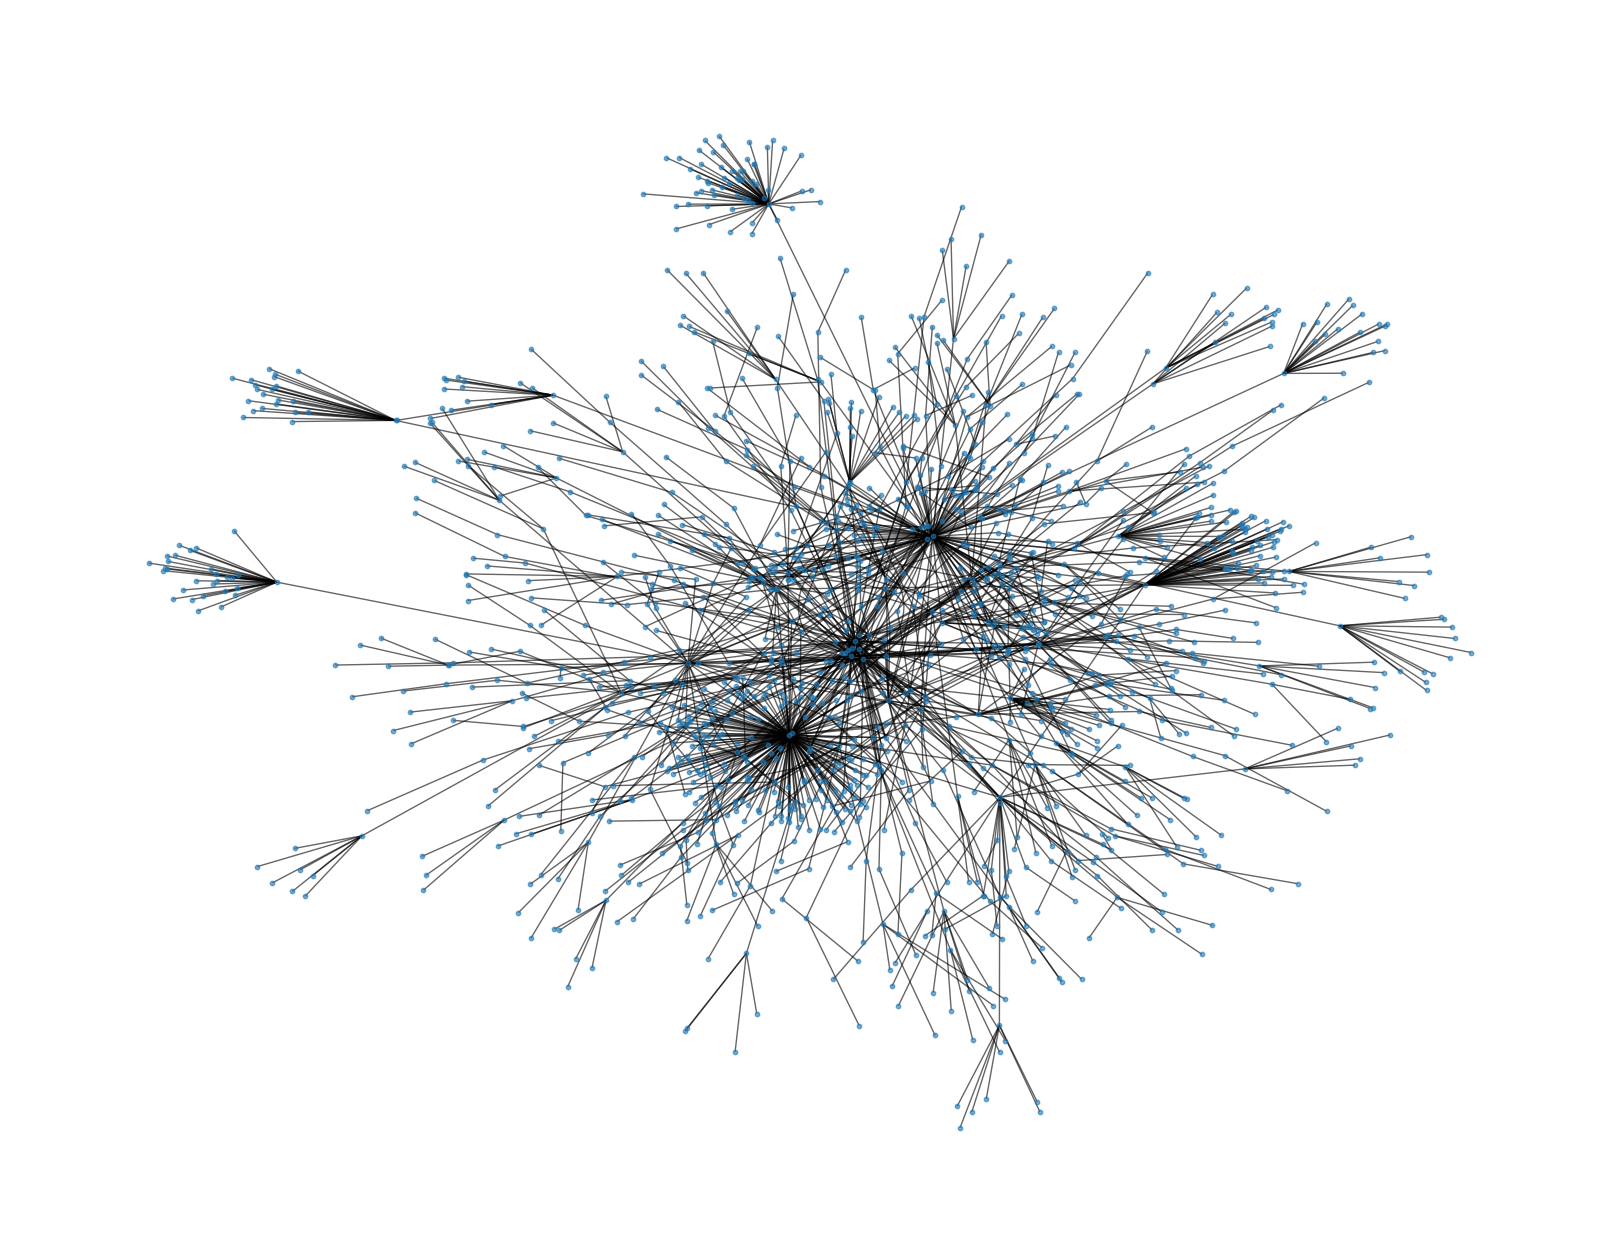

In [28]:
# NETWORK GRAPH ANALYSIS
import networkx as nx

G = nx.Graph()

sample_df = df.sample(
    min(1000, len(df)),
    random_state=42
)

for _, row in sample_df.iterrows():

    ip = row['Source IP Address']

    asn = str(row['ASN'])

    country = str(row['Country'])

    attack = str(row['Attack Type'])

    G.add_edge(ip, asn)

    G.add_edge(asn, country)

    G.add_edge(country, attack)

plt.figure(figsize=(16, 12))

pos = nx.spring_layout(
    G,
    k=0.15
)

nx.draw(

    G,

    pos,

    node_size=10,

    with_labels=False,

    alpha=0.6

)

plt.title(
    'Cybercrime Infrastructure Network'
)

plt.show()


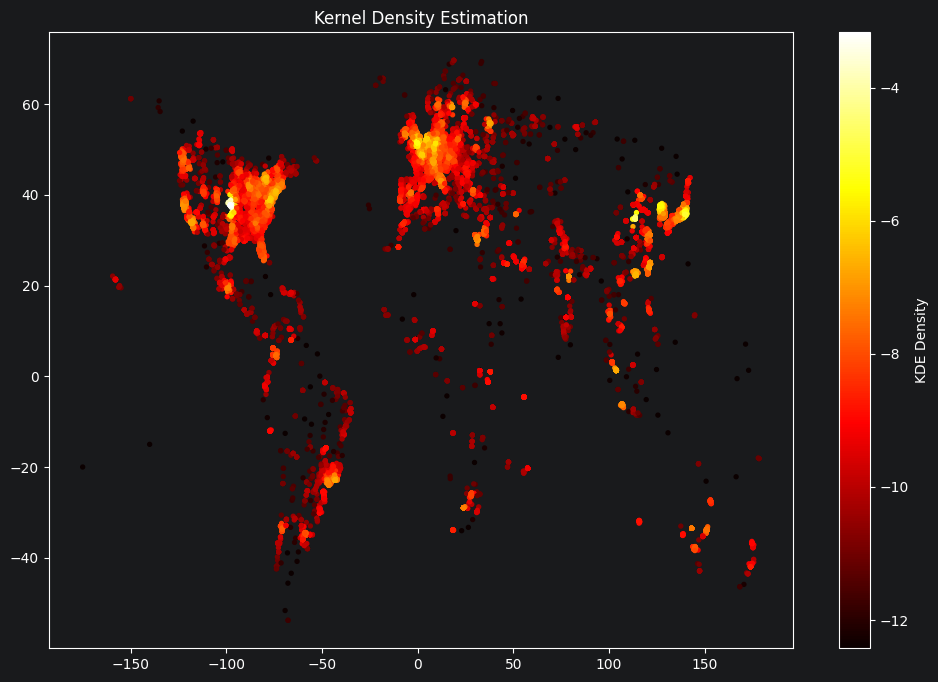

In [29]:
# KERNEL DENSITY ESTIMATION (KDE)
from sklearn.neighbors import KernelDensity

coords = np.vstack([

    df['Longitude'],
    df['Latitude']

]).T

kde = KernelDensity(

    bandwidth=1.0,
    kernel='gaussian'

)

kde.fit(coords)

density_scores = kde.score_samples(
    coords
)

df['kde_density'] = density_scores


# KDE VISUALIZATION


plt.figure(figsize=(12, 8))

plt.scatter(

    df['Longitude'],
    df['Latitude'],

    c=df['kde_density'],

    cmap='hot',

    s=8

)

plt.colorbar(
    label='KDE Density'
)

plt.title(
    'Kernel Density Estimation'
)

plt.show()

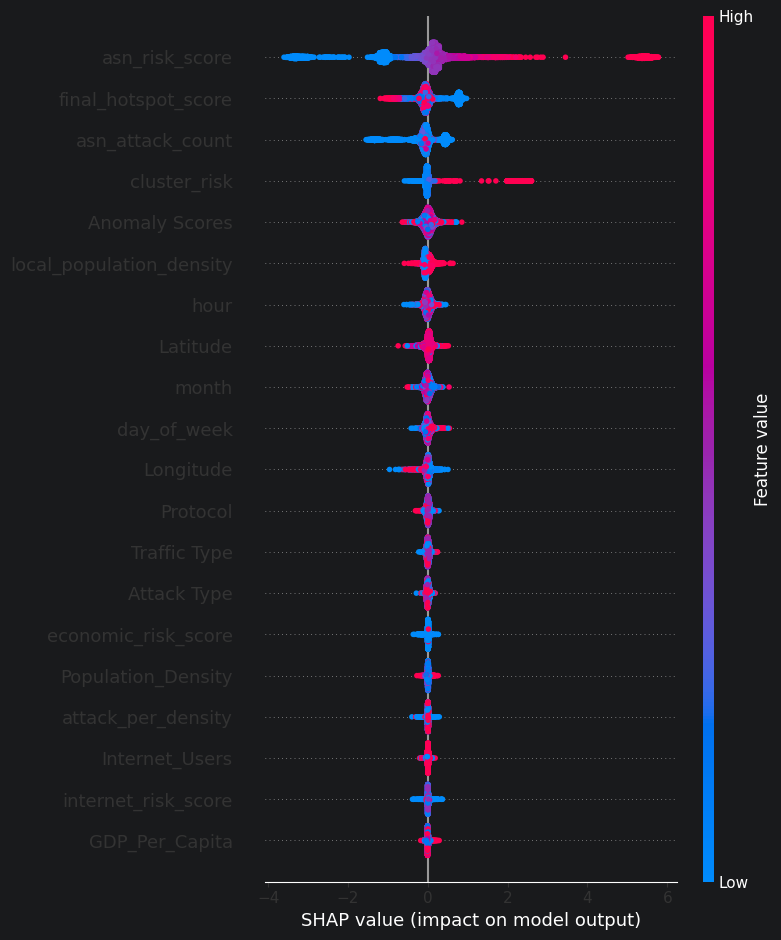

In [30]:
# SHAP EXPLAINABILITY

import shap

explainer = shap.TreeExplainer(
    xgb_model
)

shap_values = explainer.shap_values(
    X_test
)

shap.summary_plot(
    shap_values,
    X_test
)